
#  Big Data
Big Data means very large and complex data that cannot be handled using normal tools like Excel or basic databases.

It is used to store, process, and analyze huge data to get useful information.

---

##  5 V’s of Big Data
- **Volume** → Very large amount of data  
- **Velocity** → Data comes very fast  
- **Variety** → Different types of data (text, images, videos)  
- **Veracity** → Accuracy of data  
- **Value** → Useful information from data  

---

##  Pandas Limitation
- Works only in computer memory (RAM)  
- Cannot handle very large data (GB/TB level)  
- Slower for big data processing  
- Works only on single computer  

---

##  Apache Spark
Apache Spark is a big data tool used to process large datasets very fast.

- Works with large data  
- Uses multiple computers (distributed system)  
- Faster than Pandas  
- Used for batch and real-time processing  

---

##  PySpark
PySpark is the Python version of Apache Spark.

It allows us to use Spark using Python code instead of Scala or Java.

---

##  Spark vs PySpark

- **Apache Spark** → Main big data engine (written in Scala)  
- **PySpark** → Python way to use Spark  

### Simple Difference:
- Spark = Engine  
- PySpark = Python control for that engine  


In [ ]:
!pip install pyspark --quiet
print("Python Installation Complete!")

Python Installation Complete!


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as functions
from pyspark.sql.functions import year,month, to_date, col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark = SparkSession.builder \
.appName('Day_04_BigData_PySpark_Architecture') \
.config('spark.sql.adaptive.enabled','true') \
.getOrCreate()
print(f'Spark version  : {spark.version}')
print(f'SparkSession   : ACTIVE')
print(f'Application    : {spark.sparkContext.appName}')

Spark version  : 4.0.2
SparkSession   : ACTIVE
Application    : Day_04_BigData_PySpark_Architecture


 # Transformations vs Actions

**Transformations:** operations that create a new dataset from an existing one.

**Examples:**

`map()` → apply function to each element

`filter()` → select specific rows

`select(`) → choose columns

`withColumn(`) → add/modify column

`groupBy(`) → group data

`orderBy(`) → sort data

`drop()` → remove columns


**Actions:** operations that execute the transformations and give result.

Examples :

`show()` → display data

`count()` → number of rows

`collect()` → get all data to driver

`first()` → first row

`take(n)` → first n rows

`describe()` → summary statistics

#  PySpark Transformations vs Pandas vs SQL


| PySpark Transformation | Meaning | Pandas Equivalent | SQL Equivalent |
|----------------------|---------|------------------|----------------|
| `df.select("name","age")` | Choose columns | `df[["name", "age"]]` | `SELECT name,age FROM table;` |
| `df.filter(df.age > 18)` | Filter rows based on condition | `df[df["age"]>18]` | `SELECT * FROM table WHERE age > 18;` |
| `df.withColumn("new_col", df.age + 5)` | Add/modify column | `df["new_col"] = df["age"] + 5` | `SELECT age + 5 AS new_col FROM table;` |
| `drop()` | Remove column | `df.drop("col", axis=1)` | Not direct (use SELECT required cols) |
| `df.groupBy("dept").count()` | Group and count | `df.groupby("dept").count()` | `SELECT dept, COUNT(*) FROM table GROUP BY dept;` |
| `orderBy()` | Sort data | `df.sort_values()` | `ORDER BY col` |
| `withColumnRenamed()` | Rename column | `df.rename(columns={})` | `SELECT col AS new_name` |
| `distinct()` | Remove duplicates | `df["col"].unique()` | `SELECT DISTINCT col FROM table` |

---

##  Simple Understanding

- **PySpark** → Big data processing tool  
- **Pandas** → Small data processing tool  
- **SQL** → Database query language  

 All three do same work, just different ways depending on data size and system.

In [ ]:
df_bronze= spark.read.option('header','true').csv('large_sales_data.csv')
print('=== BRONZE LAYER --Raw Data ===')
print(f'Rows  : {df_bronze.count()}')
print(f'Columns:{len(df_bronze.columns)}')
print()
df_bronze.printSchema()

=== BRONZE LAYER --Raw Data ===
Rows  : 5000
Columns:13

root
 |-- order_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- revenue: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print('First 5 rows:')
df_bronze.show(5,truncate=False)

print('\n Basic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [ ]:
df_bronze.write.mode('overwrite').parquet('sales_bronze.parquet')
print('Bronze Parquet saved: sales_bronze.parquet')

Bronze Parquet saved: sales_bronze.parquet


# Parquet File Format
 **What is Parquet?**
Parquet is a columnar storage file format used in Big Data systems like Spark.

 **Why Parquet is used?**

Stores data column-wise (not row-wise)

Very fast for reading & analytics

Uses less storage space (compression)

Best for big data processing

SILVER LAYER-TRANSFORM

In [ ]:
df_silver=df_bronze.dropDuplicates().dropna(subset=['order_id','product','revenue'])
df_silver = df_silver.withColumn('order_date',to_date(col('order_date'),'yyyy-MM-dd'))

In [ ]:
df_silver = df_silver \
.withColumn('order_year',year(col('order_date'))) \
.withColumn('order_month',month(col('order_date')))

In [ ]:
df_silver = df_silver.withColumn(
    "revenue_category",
    F.when(col("revenue") > 40000, "High")
     .when(col("revenue") > 10000, "Medium")
     .otherwise("Low")
)

print(f'Silver layer rows: {df_silver.count()}')
print('New columns added: order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(4)

Silver layer rows: 5000
New columns added: order_year, order_month, revenue_category
+--------+-------+----------+-----------+----------------+
| product|revenue|order_year|order_month|revenue_category|
+--------+-------+----------+-----------+----------------+
| Printer|  12000|      2023|         11|          Medium|
|   Mouse|   8000|      2023|          7|             Low|
|  Webcam|  17500|      2023|         10|          Medium|
|Keyboard|  14400|      2023|          2|          Medium|
+--------+-------+----------+-----------+----------------+
only showing top 4 rows


In [ ]:
import os

def get_dir_size(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / 1024

    total = 0

    for dirpath, dirnames, filenames in os.walk(path):
        for file in filenames:
            file_path = os.path.join(dirpath, file)
            total += os.path.getsize(file_path)

    return total / 1024

In [ ]:
df_silver.write \
.mode('overwrite') \
.parquet('sales_silver.parquet')
print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size:{get_dir_size("sales_silver.parquet"):.1f}KB')

Silver Parquet saved: sales_silver.parquet
Silver size:63.8KB


In [ ]:
df_verify = spark.read.parquet('sales_silver.parquet')
print(f'Read-back rows:{df_verify.count()}(should match silver count)')
df_verify.printSchema()

Read-back rows:5000(should match silver count)
root
 |-- order_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- revenue: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products = df_silver\
.groupby('product')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('num_orders'),
    F.avg('revenue').alias('avg_order_revenue')
) \
.orderBy('total_revenue',ascending=False)\
.limit(5)

print('=== TOP 5 PRODUCTS BY REVENUE ===')
top_products.show(truncate=False)

=== TOP 5 PRODUCTS BY REVENUE ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |1.827E8      |502       |363944.22310756973|
|Tablet |1.35104E8    |532       |253954.8872180451 |
|Monitor|8.2126E7     |481       |170740.12474012474|
|Printer|4.4544E7     |488       |91278.68852459016 |
|Speaker|1.6317E7     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [ ]:
region_revenue = df_silver\
.groupBy('region')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('total_order'),
    F.countDistinct('customer_name').alias('unique_customers')
) \
.orderBy('total_revenue',ascending= False)
print('=== TOP 5 PRODUCTS BY REVENUE ===')
region_revenue.show(truncate=False)

=== TOP 5 PRODUCTS BY REVENUE ===
+------+-------------+-----------+----------------+
|region|total_revenue|total_order|unique_customers|
+------+-------------+-----------+----------------+
|West  |1.982756E8   |2021       |15              |
|South |1.471459E8   |1483       |15              |
|North |9.98784E7    |995        |15              |
|East  |5.05477E7    |501        |15              |
+------+-------------+-----------+----------------+



In [ ]:
gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('gold_region.parquet')
print('Gold 1 saved: gold_region_revenue.parquet')
gold_products = df_silver \
    .groupBy('product') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.sum('quantity').alias('units_sold')
    ) \
    .orderBy(F.desc('total_revenue'))

gold_products.write \
    .mode('overwrite') \
    .parquet('gold_products.parquet')

print('Gold 2 saved: gold_products.parquet')

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_products.parquet


In [ ]:
monthly_trend = df_silver \
.groupBy('order_month') \
.agg(F.sum('revenue').alias('monthly_revenue'),
     F.count('order_id').alias('monthly_orders')) \
     .orderBy('order_month')

print('=== Monthly Revenue Trend ===')
monthly_trend.show(12)

=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|      4.10682E7|           423|
|          2|      3.44854E7|           375|
|          3|      4.00312E7|           451|
|          4|      3.88571E7|           390|
|          5|      3.99845E7|           423|
|          6|      4.07074E7|           390|
|          7|      4.26407E7|           405|
|          8|      4.37185E7|           418|
|          9|      3.76402E7|           398|
|         10|       4.7839E7|           479|
|         11|      4.45771E7|           419|
|         12|      4.42983E7|           429|
+-----------+---------------+--------------+



In [ ]:
region_pd = spark.read.parquet('gold_region.parquet').toPandas()
product_pd = spark.read.parquet('gold_products.parquet').toPandas()
#monthly_pd = spark.read.parquet('monthly_trend.parquet').toPandas()

print('Gold tables converted to Pandas:')
print(f' Region :{region_pd.shape}')
print(f' Products :{product_pd.shape}')
  # print(f' Monthly :{monthly_pd.shape}')

Gold tables converted to Pandas:
 Region :(4, 4)
 Products :(10, 3)


In [ ]:
print('Gold tables converted to Pandas')
print(f'Region : {region_pd.shape}')
print(f'Products : {product_pd.shape}')

Gold tables converted to Pandas
Region : (4, 4)
Products : (10, 3)


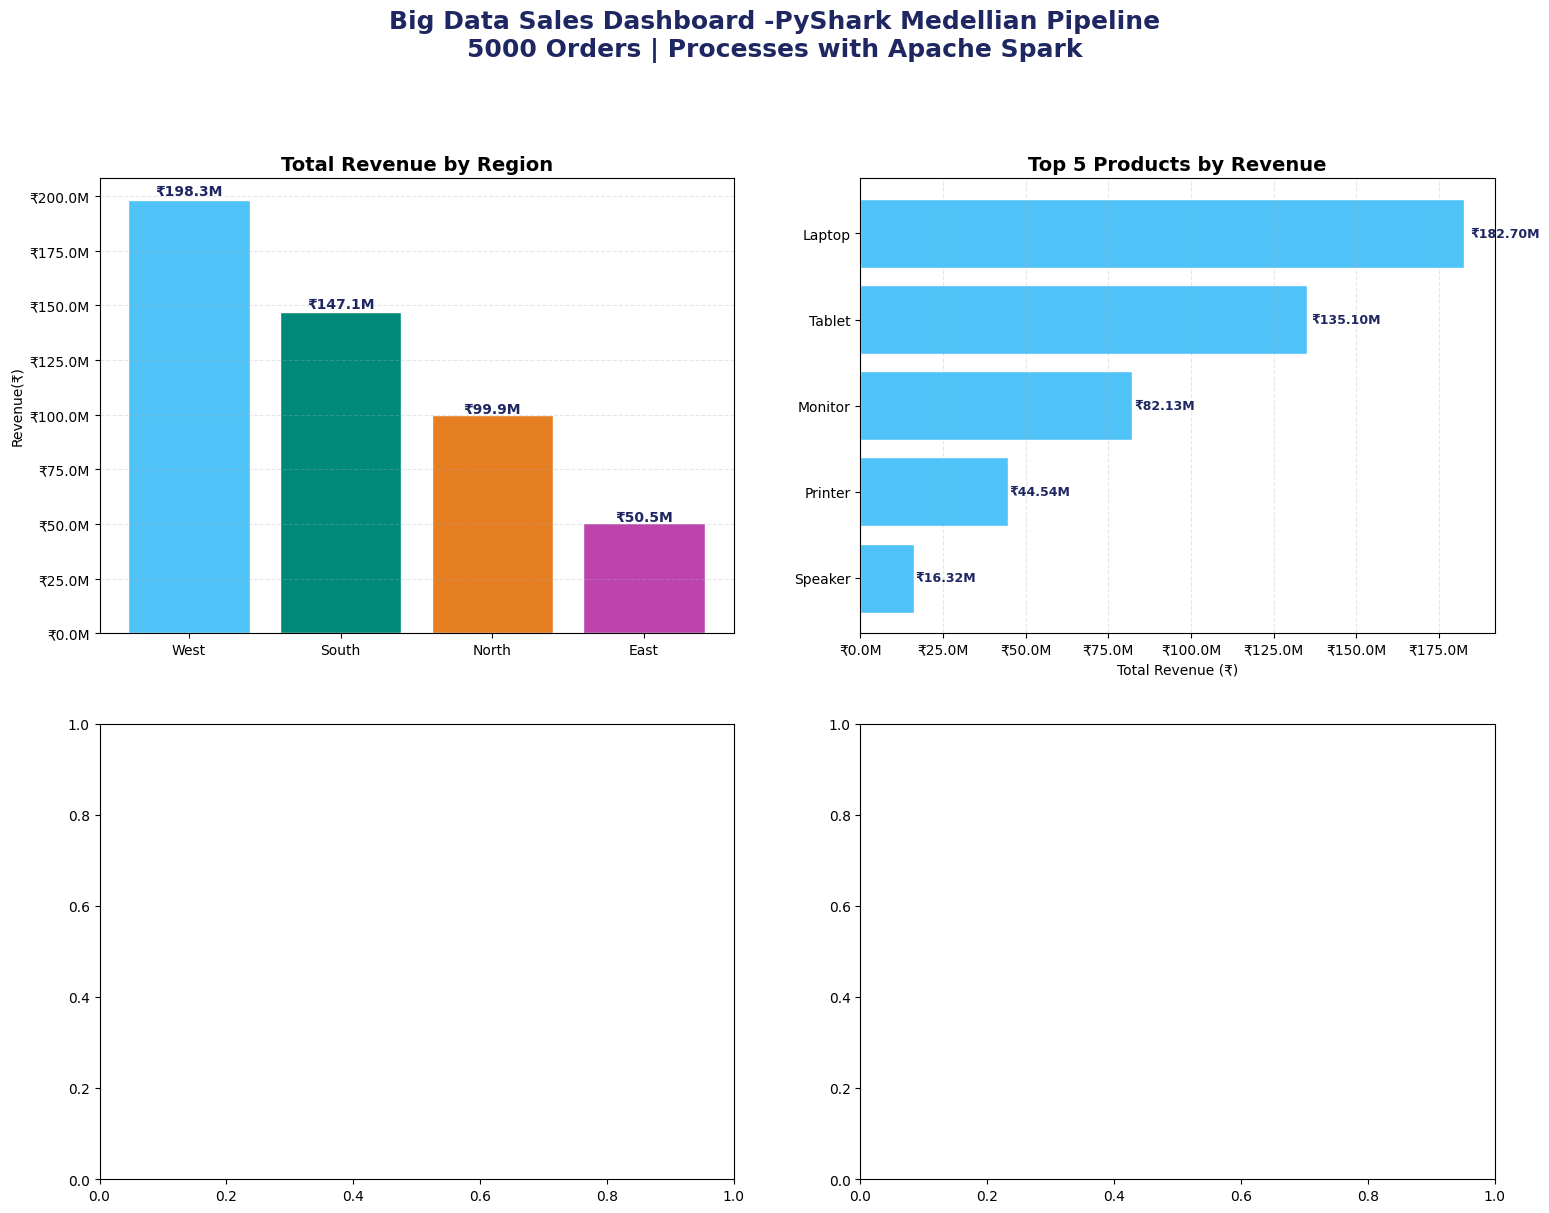

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
     'Big Data Sales Dashboard -PyShark Medellian Pipeline\n'
     '5000 Orders | Processes with Apache Spark',
     fontsize=18,fontweight='bold',color='#1E2761',y=1.01

)
colors=['#4FC3F7','#008978','#E67E22','#BE44AD','#E74C3C']
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],
              color=colors[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue(₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y',alpha=0.3,linestyle='--')
ax2=axes[0][1]
top5_prod = product_pd.head(5).sort_values('total_revenue')
bars2=ax2.barh(top5_prod['product'],top5_prod['total_revenue'],
               color='#4FC3F7',edgecolor='white')
for bar in bars2:
  ax2.text(bar.get_width()*1.01,bar.get_y()+bar.get_height()/2,
           f'₹{bar.get_width()/1e6:.2f}M',
           va='center',fontsize=9,fontweight='bold',color='#1E2761')
ax2.set_title('Top 5 Products by Revenue',fontsize=14,fontweight='bold')
ax2.set_xlabel('Total Revenue (₹)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'₹{x/1e6:.1f}M'))
ax2.grid(axis='x',alpha=0.3,linestyle='--')